# Homogeneous Circle

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('spawn')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit.nurbs import NURBS

from ttnte.xs.benchmarks import pu239
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import power, LinearSolverOptions
from ttnte.cad import Patch
from ttnte.cad.surfaces import circle

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
xs_server = pu239(num_groups=1)

In [3]:
rc = 4.279960 # Critical radius (cm)

# Create mesh
mesh = IGAMesh()
mesh.add_patch(Patch(circle(rc), "Pu-239"))

# Refine mesh resolution
mesh.refine(factor=10, degree=4)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Pu-239, source=None, id=0, name=None, shape=(14, 14), backend=geomdl)

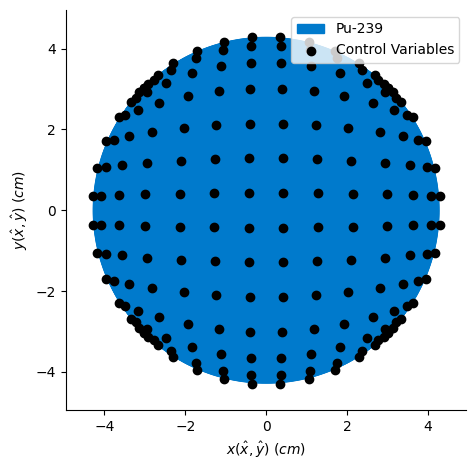

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/circle.png", dpi=300, transparent=True)
plt.show()

## Assemble TT Operators

In [5]:
# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=True, eps=1e-5)

# Save TT information
assembler.save_info("./tt_info.csv")

Running TTAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 14, B = 14
Operators: H, S, F, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 51.33 s)
Step            Ranks                     Compression
H               3,3,3,31                  15064358.87
S               1,1,1,8                   123944909.59
F               1,1,1,8                   123944909.59
B_out           4,66,49,29                 166703.96


## Solve and Check Eigenvalue

In [6]:
psi, k = power(
    T=(tts.H + tts.B_out - tts.S).round(1e-5),
    F=tts.F,
    tol=1e-8,
    maxiter=1000,
    gpu_idx=0,
    lsoptions=LinearSolverOptions(
        tol=1e-10,
        maxiter=5,
        restart=30,
    )
)
psi = psi.reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

# Calculate eigenvalue error
print("keff error: {} pcm".format((k - 1) * 1e5))

Running power iteration on GPU 0


-- (0): k = 0.939764, Angular Flux L2-Error = 0.572778988887, Elapsed Time = 24.605 s


-- (1): k = 0.980473, Angular Flux L2-Error = 0.118225015121, Elapsed Time = 49.201 s


-- (2): k = 0.993221, Angular Flux L2-Error = 0.039909845727, Elapsed Time = 73.795 s


-- (3): k = 0.997560, Angular Flux L2-Error = 0.014593663013, Elapsed Time = 98.390 s


...

-- (272): k = 0.999996, Angular Flux L2-Error = 0.000000010166, Elapsed Time = 6714.578 s


-- (273): k = 0.999996, Angular Flux L2-Error = 0.000000010889, Elapsed Time = 6739.174 s


-- (274): k = 0.999996, Angular Flux L2-Error = 0.000000009686, Elapsed Time = 6763.770 s


-- Converged!


keff error: -0.445207449717433 pcm


## Plot and Compare to Analytical Solution

$$
\begin{aligned}
\delta \phi(r, \theta) &= \frac{\phi^{\text{ref}}(0)}{\phi^{\text{ref}}(r)}\left(\frac{\phi^{\text{TDIGA}}(r, \theta)}{\phi^{\text{TDIGA}}(0, \theta)} - \frac{\phi^{\text{ref}}(r)}{\phi^{\text{ref}}(0)}\right)\\
\epsilon_2(r) &= \frac{\phi^{\text{ref}}(0)}{\phi^{\text{ref}}(r)}\sqrt{\frac{1}{2\pi}\int_{0}^{2\pi}\left(\frac{\phi^{\text{TDIGA}}(r, \theta)}{\phi^{\text{TDIGA}}(0, \theta)} - \frac{\phi^{\text{ref}}(r)}{\phi^{\text{ref}}(0)}\right)^2d\theta}
\end{aligned}
$$
where
$$
\begin{aligned}
    \frac{\phi^{\text{ref}}(0.5r_c)}{\phi^{\text{ref}}(0)} &= 0.8093\\
    \frac{\phi^{\text{ref}}(r_c)}{\phi^{\text{ref}}(0)} &= 0.2926
\end{aligned}
$$

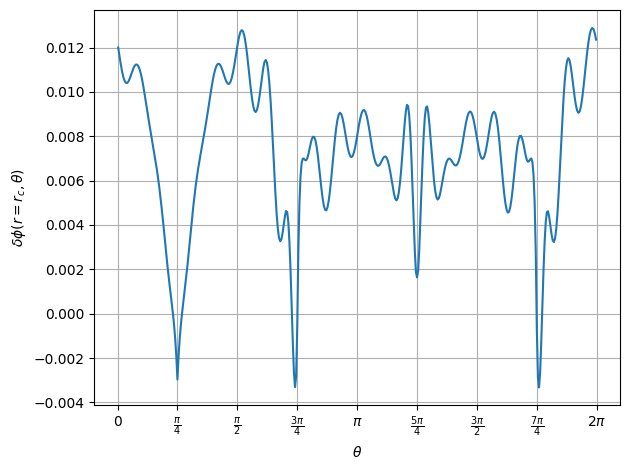

L2-error = 0.007892230814305923


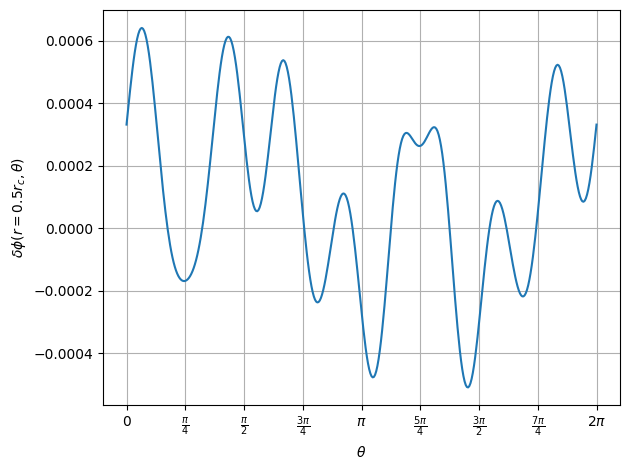

L2-error = 0.00030968345708904657


In [7]:
def evaluate_boundary(mesh):
    # Plot and evaluate boundary flux
    center_flux = mesh((0.5, 0.5))[0][-1]
    points = np.zeros((400, 2))
    points[:100, 0] = np.linspace(0, 1, 100)
    points[100:200, 0] = 1
    points[100:200, 1] = np.linspace(0, 1, 100)
    points[200:300, 0] = np.linspace(0, 1, 100)[::-1]
    points[200:300, 1] = 1
    points[300:400, 1] = np.linspace(0, 1, 100)[::-1]

    points = mesh(points)[0]
    points[:, -1] /= center_flux

    # Convert to angle
    angular_points = np.zeros((points.shape[0], 2))
    angular_points[:, -1] = points[:, -1]
    angular_points[(points[:, 0] >= 0), 0] = np.arcsin(
        points[(points[:, 0] >= 0), 1] / rc
    )
    angular_points[(points[:, 0] < 0) & (points[:, 1] >= 0), 0] = (
        -np.arcsin(points[(points[:, 0] < 0) & (points[:, 1] >= 0), 1] / rc) + np.pi
    )
    angular_points[(points[:, 0] < 0) & (points[:, 1] < 0), 0] = (
        -np.arcsin(points[(points[:, 0] < 0) & (points[:, 1] < 0), 1] / rc) - np.pi
    )
    return angular_points[angular_points[:, 0].argsort()]

def evaluate_radius(mesh, radius, tol):
    # Plot and evaluate boundary flux
    center_flux = mesh((0.5, 0.5))[0][-1]

    # Calculate physical locations
    points = radius * np.ones((400, 2))
    angular_points = np.zeros((400, 2))
    angular_points[:, 0] = np.linspace(-np.pi, np.pi, 400)
    points[:, 0] *= np.cos(angular_points[:, 0])
    points[:, 1] *= np.sin(angular_points[:, 0])

    # Inverse map to the parametric domain
    points = mesh(mesh.inverse_map(points, tol=tol)[-1])[0][:, -1]
    angular_points[:, 1] = points / center_flux

    return angular_points

# Set flux and get patch
mesh.set_phi(phi)

# Plot scalar flux solution at rc
points = evaluate_boundary(mesh)
plt.clf()
plt.plot(points[:, 0] + np.pi, (points[:, 1] - 0.2926) / 0.2926)
plt.ylabel(r"$\delta\phi(r = r_c, \theta)$")
plt.xlabel(r"$\theta$")
plt.xticks(
    [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi, 5 * np.pi / 4, 3 * np.pi / 2, 7 * np.pi / 4,  2 * np.pi],
    [
        "$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
         r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$",
    ]
)
plt.grid()
plt.tight_layout()
plt.savefig("./figs/r_1.png", dpi=300, transparent=True)
plt.show()

# Calculate L2-error
print(
    "L2-error = {}".format(
        np.sqrt(np.trapz((points[:, 1] - 0.2926) ** 2, points[:, 0]))
        / np.sqrt(2 * np.pi * 0.2926**2)
    )
)

# Plot scalar flux solution at 0.5rc
points = evaluate_radius(mesh, 0.5 * rc, tol=1e-10)
plt.clf()
plt.plot(points[:, 0] + np.pi, (points[:, 1] - 0.8093) / 0.8093)
plt.ylabel(r"$\delta\phi(r = 0.5r_c, \theta)$")
plt.xlabel(r"$\theta$")
plt.xticks(
    [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi, 5 * np.pi / 4, 3 * np.pi / 2, 7 * np.pi / 4,  2 * np.pi],
    [
        "$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
         r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$",
    ]
)
plt.grid()
plt.tight_layout()
plt.savefig("./figs/r_0.5.png", dpi=300, transparent=True)
plt.show()

# Calculate L2-error
print(
    "L2-error = {}".format(
        np.sqrt(np.trapz((points[:, 1] - 0.8093) ** 2, points[:, 0]))
        / np.sqrt(2 * np.pi * 0.8093**2)
    )
)

<Figure size 640x480 with 0 Axes>

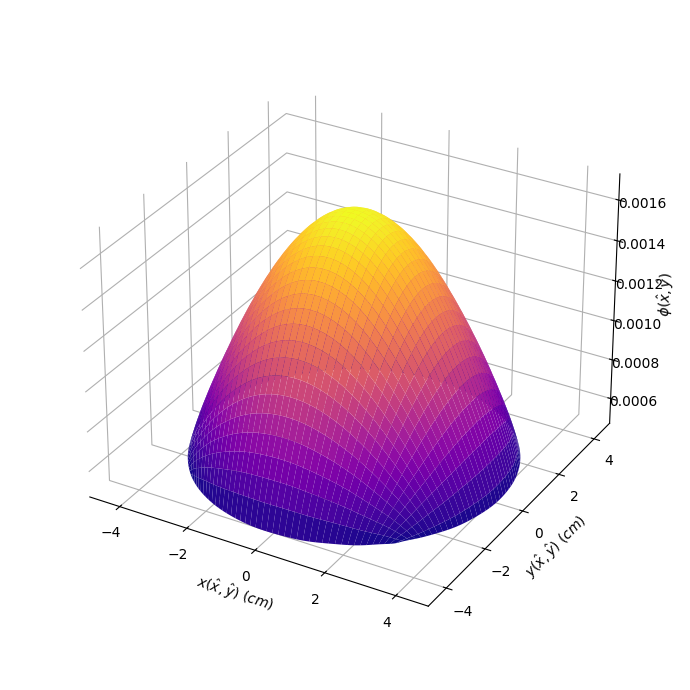

In [8]:
# Plot
plt.clf()
ax = mesh.plot(plot_ctrlpts=False, use_3d=True, figsize=(7, 7))
ax.set_zlabel(r"$\phi(\hat{x}, \hat{y})$")
ax.set_box_aspect(None, zoom=0.9)
plt.tight_layout()
plt.savefig("./figs/phi_1.png", dpi=300, transparent=True)
plt.show()